In [1]:
import matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.signal import find_peaks
from matplotlib.collections import LineCollection
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import utils
import nist_codes

try:
    import nist_helper
    descriptor_tokens = [t.lower() for t in getattr(nist_helper, "NIST_DESCRIPTORS", [])]
except Exception:
    nist_helper = None
    descriptor_tokens = []

In [2]:
HE_SHEET = "he test.xlsx"

df = pd.read_excel(HE_SHEET)
df_filtered = df[(df['nm'] >= 400) & (df['nm'] <= 750)].copy()

# Sort by 'nm' to ensure correct neighbor comparison and plotting order
df_filtered = df_filtered.sort_values(by='nm').reset_index(drop=True)

print("DataFrame loaded successfully. Here are the first 5 rows:")
print(df.head())

DataFrame loaded successfully. Here are the first 5 rows:
   Unnamed: 0  Grey Val         nm  Unnamed: 3    Unnamed: 4  Unnamed: 5  \
0        2178   247.148  589.03701         NaN  max grey val         NaN   
1        2179   246.463  587.91075         NaN       247.148         NaN   
2        2180   243.830  586.78449         NaN           NaN         NaN   
3        2181   241.833  585.65823         NaN  min grey val         NaN   
4        2177   240.733  590.16327         NaN        16.674         NaN   

   Unnamed: 6 Unnamed: 7  
0  3042.03129   -1.12626  
1         NaN        NaN  
2         NaN        NaN  
3         NaN        NaN  
4         NaN    he_3584  


In [30]:
rgb = utils.wavelength_to_rgb

y_title = 'Intensity'
x_title = 'Wavelength (nm)'
fig_size = (15,6)
prominence = 0.12
min_bright = 0.1
min_alpha = 0.1
bar_width = 1
smoothing_window = 5    # Increase this value to control the degree of smoothing
x_min = 400
x_max = 750
mode = 'dark'
reverse_x = True
show_grid = True
plot_type = None

df_filtered['Smoothed_int'] = df_filtered['Grey Val'].rolling(window=smoothing_window, center=True).mean().fillna(df_filtered['Grey Val'])

if plot_type == 'Smoothed':
    min_int = df_filtered['Smoothed_int'].min
    max_int = df_filtered['Smoothed_int'].max
else:
    min_int = df_filtered['Grey Val'].min()
    max_int = df_filtered['Grey Val'].max()

int_range = max_int - min_int

if int_range == 0:
    df_filtered['Normalized_int'] = 1.0
else:
    if plot_type == 'Smoothed':
        df_filtered['Normalized_int'] = (df_filtered['Smoothed_int'] - min_int) / int_range
    else:
        df_filtered['Normalized_int'] = (df_filtered['Grey Val'] - min_int) / int_range

In [4]:
def axis_labels():
    ax = plt.gca()

    if mode == 'dark':
        fig_bg = 'black'
        text = 'white'
        plt.gcf().set_facecolor('black')
        if show_grid is True:
            plt.grid(show_grid, color='darkgrey', linestyle=':', linewidth=0.5)
    else:
        fig_bg = 'white'
        text = 'black'
        if show_grid is True:
            plt.grid(show_grid)
    
    if reverse_x is True:
        plt.xlim(x_max, x_min)
    else:
        plt.xlim(x_min, x_max)

    ax.set_facecolor(fig_bg)
    plt.xlabel(x_title, color=text)
    plt.ylabel(y_title, color=text)
    plt.xticks(color=text)
    plt.yticks(color=text)

In [19]:
def dynamic_prominence(prominence, int_range):
    dyn_prom = prominence * int_range
    return dyn_prom

In [5]:
def final_alpha(alpha_min, alpha_factor):
    final_alpha = alpha_min + (1 - alpha_min) * alpha_factor
    return final_alpha

In [6]:
def final_int_scale(int_factor):
    final_intensity_scale = min_bright + (1 - min_bright) * int_factor
    return final_intensity_scale

In [7]:
def colored_rgb(base_rgb, final_intensity_scale):
    colored_rgb = (base_rgb[0] * final_intensity_scale,
                   base_rgb[1] * final_intensity_scale,
                   base_rgb[2] * final_intensity_scale)
    return colored_rgb

In [31]:
def filled_plot():
    plt.figure(figsize=fig_size) 
    axis_labels()
    
    for i in range(len(df_filtered) - 1):
        wavelength_start = df_filtered.iloc[i]['nm']
        wavelength_end = df_filtered.iloc[i+1]['nm']

        base_rgb = rgb(wavelength_start)

        alpha_factor = df_filtered.iloc[i]['Normalized_int']
        alpha = final_alpha(min_alpha, alpha_factor)

        if plot_type == 'Smoothed':
            plt.fill_between([wavelength_start, wavelength_end],
                     [0, 0], # Base of the fill is y=0
                     [df_filtered.iloc[i]['Smoothed_int'], df_filtered.iloc[i+1]['Smoothed_int']], # Top of the fill
                     color=base_rgb,
                     alpha=alpha,
                     linewidth=0) # No line for the fill edges
        else:
            plt.fill_between([wavelength_start, wavelength_end],
                        [0, 0], # Base of the fill is y=0
                        [df_filtered.iloc[i]['Grey Val'], df_filtered.iloc[i+1]['Grey Val']], # Top of the fill
                        color=base_rgb,
                        alpha=alpha,
                        linewidth=0) # No line for the fill edges

              # Plot the line on top for clarity, using the base color for the line itself
            plt.plot([wavelength_start, wavelength_end],
                    [df_filtered.iloc[i]['Grey Val'], df_filtered.iloc[i+1]['Grey Val']],
                    color=base_rgb,
                    linewidth=2) # Thicker line for better visibility on top of fill

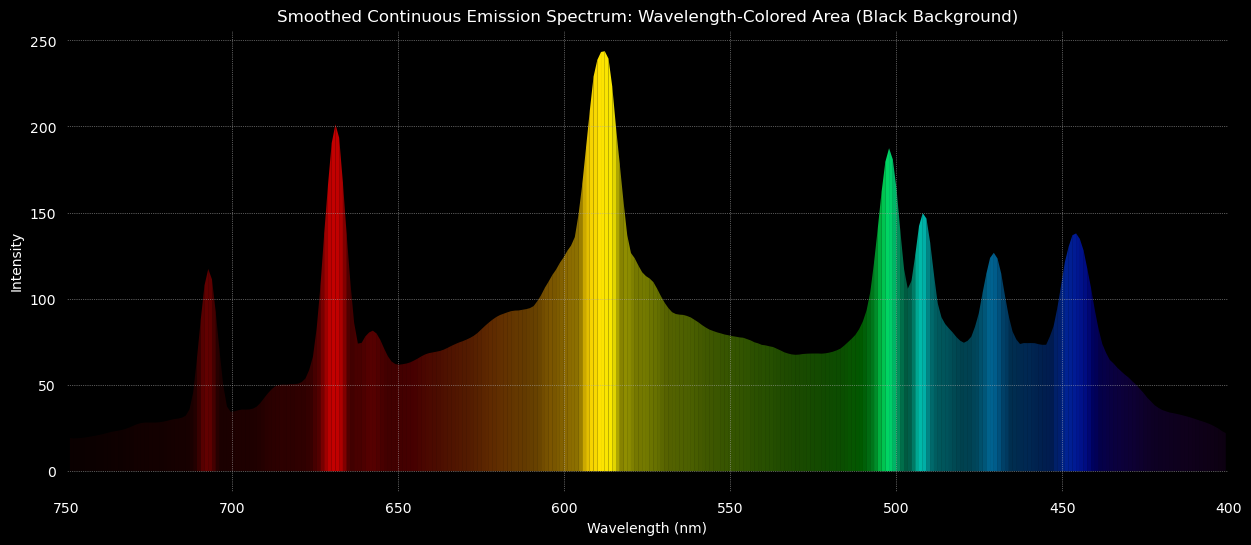

This visualization presents the emission spectrum as a smoothed, continuous area plot against a black background.
A rolling mean has been applied to the 'Grey Val' data to create a smoother curve.
Each segment's color is determined by its wavelength, and its opacity (alpha) is scaled by its intensity, providing a glowing representation.


In [25]:
mode = 'dark'
plot_type = 'Smoothed'


filled_plot()

plt.title('Smoothed Continuous Emission Spectrum: Wavelength-Colored Area (Black Background)', color='white')
plt.show()

print("This visualization presents the emission spectrum as a smoothed, continuous area plot against a black background.")
print("A rolling mean has been applied to the 'Grey Val' data to create a smoother curve.")
print("Each segment's color is determined by its wavelength, and its opacity (alpha) is scaled by its intensity, providing a glowing representation.")